In [ ]:
install.packages("RSQLite", repos = "https://cloud.r-project.org/")
install.packages("sqldf", repos = "https://cloud.r-project.org/")
install.packages("dplyr", repos = "https://cloud.r-project.org/")


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
# Install and load required packages
install.packages("sqldf")
install.packages("ggplot2")
install.packages("dplyr")

library(sqldf)
library(ggplot2)
library(dplyr)



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
# Load all NorthStar CSV files
customers  <- read.csv("customers.csv",  stringsAsFactors = FALSE)
orders     <- read.csv("orders.csv",     stringsAsFactors = FALSE)
deliveries <- read.csv("deliveries.csv", stringsAsFactors = FALSE)
complaints <- read.csv("complaints.csv", stringsAsFactors = FALSE)
drivers    <- read.csv("drivers.csv",    stringsAsFactors = FALSE)
vehicles   <- read.csv("vehicles.csv",   stringsAsFactors = FALSE)
hubs       <- read.csv("hubs.csv",       stringsAsFactors = FALSE)
incidents  <- read.csv("incidents.csv",  stringsAsFactors = FALSE)

# Verify loading
cat("Orders loaded:    ", nrow(orders),     "\n")
cat("Deliveries loaded:", nrow(deliveries), "\n")
cat("Complaints loaded:", nrow(complaints), "\n")

Orders loaded:     1250 
Deliveries loaded: 950 
Complaints loaded: 320 


In [ ]:
list.files()

[1] "app_events.csv"      "complaints.csv"      "customers.csv"      
 [4] "data_dictionary.csv" "deliveries.csv"      "drivers.csv"        
 [7] "hubs.csv"            "incidents.csv"       "orders.csv"         
[10] "README.txt"          "sample_data"         "vehicles.csv"

**Query 1 — SELECT and WHERE: Failed Deliveries**

The first query demonstrates basic SELECT and WHERE syntax. It retrieves all failed deliveries ordered by route distance so that the costliest failures appear first.

In [ ]:
# Query 1: Failed deliveries ordered by route distance
query1 <- sqldf(
  "SELECT delivery_id,
          order_id,
          driver_id,
          delivery_status,
          route_distance_km,
          fuel_or_charge_cost,
          manual_route_override_count
   FROM   deliveries
   WHERE  delivery_status = 'Failed'
   ORDER  BY route_distance_km DESC
   LIMIT  10"
)

print(query1)

   delivery_id order_id driver_id delivery_status route_distance_km
1      DL00240   O01169      D131          Failed             38.25
2      DL00938   O01246      D132          Failed             36.94
3      DL00533   O00543      D135          Failed             34.15
4      DL00935   O00211      D107          Failed             32.42
5      DL00119   O01011      D076          Failed             32.37
6      DL00312   O00204      D142          Failed             31.38
7      DL00530   O00756      D095          Failed             30.51
8      DL00438   O00992      D083          Failed             27.82
9      DL00400   O00867      D165          Failed             25.59
10     DL00574   O00693      D048          Failed             24.31
   fuel_or_charge_cost manual_route_override_count
1                21.21                           1
2                20.16                           0
3                21.32                           2
4                14.69                          

Query 2 — GROUP BY and COUNT: Delivery Outcomes by Service Type

This query uses GROUP BY and COUNT to summarise delivery outcomes across each service type. This directly addresses the Finance Director's concern that some service lines may be systematically unprofitable.

In [ ]:
# Query 2: Delivery outcome counts grouped by service type
query2 <- sqldf(
  "SELECT   o.service_type,
            d.delivery_status,
            COUNT(*)                     AS total_deliveries,
            ROUND(AVG(o.order_value), 2) AS avg_order_value
   FROM     deliveries d
   JOIN     orders o ON d.order_id = o.order_id
   GROUP BY o.service_type, d.delivery_status
   ORDER BY o.service_type, d.delivery_status"
)

print(query2)

   service_type delivery_status total_deliveries avg_order_value
1      Business         Delayed               28          108.57
2      Business          Failed               25          108.40
3      Business          OnTime               73           89.44
4       Medical         Delayed               22           85.50
5       Medical          Failed               16          107.84
6       Medical          OnTime               70           81.98
7        Parcel         Delayed               49           94.19
8        Parcel          Failed               25           68.58
9        Parcel          OnTime              156           92.34
10    Passenger         Delayed               53           81.27
11    Passenger          Failed               38           85.08
12    Passenger          OnTime              171          104.81
13       Retail         Delayed               50           82.04
14       Retail          Failed               28           94.54
15       Retail          

Query 3 — Three-Table JOIN: Customers, Orders and Deliveries

This query joins three tables — customers, orders, and deliveries — to identify which customer types experience the highest failure rates and lowest satisfaction scores. This addresses the Customer Experience Director's need for a unified view linking customer profiles to service outcomes.

In [ ]:
# Query 3: Failure rate by customer type using a 3-table JOIN
query3 <- sqldf(
  "SELECT   c.customer_type,
            COUNT(*)                                            AS total_orders,
            SUM(CASE WHEN d.delivery_status = 'Failed'  THEN 1 ELSE 0 END) AS failed,
            SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed,
            ROUND(AVG(c.loyalty_score), 2)                     AS avg_loyalty_score,
            ROUND(AVG(d.customer_rating_post_delivery), 2)     AS avg_rating
   FROM     customers c
   JOIN     orders o     ON c.customer_id = o.customer_id
   JOIN     deliveries d ON o.order_id    = d.order_id
   GROUP BY c.customer_type
   ORDER BY failed DESC"
)
print(query3)

  customer_type total_orders failed delayed avg_loyalty_score avg_rating
1      Consumer          702     97     152             60.73       3.87
2           SME          160     27      27             56.65       3.85
3    Enterprise           88      8      23             58.46       3.86


Query 4 — Multiple WHERE Conditions: High-Risk Deliveries

This query uses multiple AND conditions to identify the highest-risk deliveries: those that simultaneously failed, have missing proof of completion, and involved at least one manual route override. These records represent the accountability gaps most likely to generate disputes and compensation claims.

In [ ]:
# Query 4: High-risk deliveries — failed AND missing proof AND overridden
query4 <- sqldf(
  "SELECT d.delivery_id,
          d.order_id,
          d.driver_id,
          d.delivery_status,
          d.proof_of_completion_missing,
          d.manual_route_override_count,
          d.customer_rating_post_delivery,
          o.pickup_zone,
          o.service_type
   FROM   deliveries d
   JOIN   orders o ON d.order_id = o.order_id
   WHERE  d.delivery_status            = 'Failed'
   AND    d.proof_of_completion_missing = 1
   AND    d.manual_route_override_count > 0
   ORDER  BY d.manual_route_override_count DESC"
)

cat("High-risk deliveries identified:", nrow(query4), "\n")
print(query4)

High-risk deliveries identified: 14 
   delivery_id order_id driver_id delivery_status proof_of_completion_missing
1      DL00041   O00750      D100          Failed                           1
2      DL00505   O00833      D170          Failed                           1
3      DL00515   O00619      D130          Failed                           1
4      DL00731   O00386      D158          Failed                           1
5      DL00789   O00536      D103          Failed                           1
6      DL00178   O01166      D024          Failed                           1
7      DL00783   O00380      D099          Failed                           1
8      DL00839   O00566      D078          Failed                           1
9      DL00261   O00445      D051          Failed                           1
10     DL00482   O00777      D141          Failed                           1
11     DL00664   O00430      D152          Failed                           1
12     DL00838   O00909    

Query 5 — HAVING Clause: Drivers with Persistent Override Behaviour

This query aggregates manual route overrides by driver and uses HAVING to return only drivers who have accumulated more than 10 total overrides. HAVING filters on aggregated values and cannot be replaced by WHERE — this demonstrates an important SQL distinction.

In [ ]:
# Query 5: Drivers with more than 10 total manual route overrides
query5 <- sqldf(
  "SELECT   d.driver_id,
            dr.base_zone,
            dr.employment_type,
            dr.driver_rating,
            dr.training_score,
            COUNT(d.delivery_id)                          AS total_deliveries,
            SUM(d.manual_route_override_count)            AS total_overrides,
            ROUND(AVG(d.customer_rating_post_delivery),2) AS avg_rating
   FROM     deliveries d
   JOIN     drivers dr ON d.driver_id = dr.driver_id
   GROUP BY d.driver_id, dr.base_zone, dr.employment_type,
            dr.driver_rating, dr.training_score
   HAVING   SUM(d.manual_route_override_count) > 10
   ORDER BY total_overrides DESC"
)

print(query5)

   driver_id base_zone employment_type driver_rating training_score
1       D127   CENTRAL        FullTime          4.19           61.5
2       D087     north        Contract          4.43           73.3
3       D130      WEST        FullTime          3.64           71.2
4       D108     South        FullTime          4.33           70.6
5       D131     SOUTH        FullTime          4.26           86.7
6       D069     NORTH        PartTime          5.00           61.5
7       D105 RiverSide        Contract          3.71           82.0
8       D017      EAST        PartTime          4.34             NA
9       D028     North        FullTime          4.07           83.0
10      D008     SOUTH        FullTime          3.88           84.1
11      D026     NORTH        PartTime          3.15           84.9
12      D104      WEST        FullTime          3.45           87.7
13      D027   AIRPORT        PartTime          3.70           74.3
14      D033     South        PartTime          

 Query 6 — Complaint-Delivery JOIN: Unresolved High-Severity Cases

This query joins the complaints table with orders and deliveries to produce a combined view of unresolved high-severity complaints alongside the delivery outcome for the same order. This reveals the critical status contradiction identified in Section 2 — cases where a complaint is open but the delivery is marked complete.

In [ ]:
# Query 6: High-severity open complaints linked to delivery records
query6 <- sqldf(
  "SELECT   cp.complaint_id,
            cp.customer_id,
            cp.complaint_type,
            cp.severity,
            cp.status             AS complaint_status,
            cp.resolution_days,
            cp.compensation_amount,
            d.delivery_status,
            d.proof_of_completion_missing,
            o.service_type,
            o.order_value
   FROM     complaints cp
   JOIN     orders o     ON cp.order_id = o.order_id
   JOIN     deliveries d ON o.order_id  = d.order_id
   WHERE    cp.severity = 'High'
   AND      cp.status IN ('Open', 'Escalated')
   ORDER BY cp.resolution_days DESC"
)
cat("High-severity unresolved complaints:", nrow(query6), "\n")
print(head(query6, 10))

High-severity unresolved complaints: 15 
   complaint_id customer_id  complaint_type severity complaint_status
1        CP0030       C0529           Delay     High        Escalated
2        CP0294       C0339        AppIssue     High             Open
3        CP0261       C0566        AppIssue     High             Open
4        CP0003       C0469           Delay     High             Open
5        CP0150       C0546          Damage     High        Escalated
6        CP0133       C0480           Delay     High             Open
7        CP0147       C0383 DriverBehaviour     High             Open
8        CP0159       C0372           Delay     High        Escalated
9        CP0131       C0583           Delay     High             Open
10       CP0092       C0031 DriverBehaviour     High        Escalated
   resolution_days compensation_amount delivery_status
1               22               34.84         Delayed
2               19               39.64          Failed
3               18      

Query Optimisation: Rewriting an Inefficient Query

This section demonstrates query optimisation by comparing an unoptimised query against a restructured equivalent that produces the same result more efficiently. The two key principles are: (1) filter early using WHERE or subqueries before joining, and (2) avoid SELECT * in favour of named columns only.

3.8.1 Unoptimised Query

In [ ]:
slow_query <- sqldf(
  "SELECT *
   FROM   complaints cp
   JOIN   orders o     ON cp.order_id = o.order_id
   JOIN   deliveries d ON o.order_id  = d.order_id
   WHERE  cp.severity = 'High'
   AND    cp.status   = 'Open'"
)
cat("Rows returned:", nrow(slow_query), "\n")

Rows returned: 10 


Optimised Query

In [ ]:
# OPTIMISED version — pre-filter before joining

# Step 1: Create a small filtered subset of complaints only
high_open <- sqldf(
  "SELECT complaint_id, customer_id, order_id,
          complaint_type, resolution_days, compensation_amount
   FROM   complaints
   WHERE  severity = 'High'
   AND    status   = 'Open'"
)
# Step 2: Join the smaller subset to orders and deliveries
optimised_query <- sqldf(
  "SELECT hoc.complaint_id,
          hoc.complaint_type,
          hoc.resolution_days,
          hoc.compensation_amount,
          o.service_type,
          o.order_value,
          d.delivery_status,
          d.route_distance_km
   FROM   high_open hoc
   JOIN   orders o     ON hoc.order_id = o.order_id
   JOIN   deliveries d ON o.order_id   = d.order_id
   ORDER  BY hoc.resolution_days DESC"
)
cat("Rows returned (optimised):", nrow(optimised_query), "\n")
print(head(optimised_query, 8))

Rows returned (optimised): 10 
  complaint_id  complaint_type resolution_days compensation_amount service_type
1       CP0294        AppIssue              19               39.64      Medical
2       CP0261        AppIssue              18               47.09     Business
3       CP0003           Delay              16               26.41      Medical
4       CP0133           Delay              15               38.76       Parcel
5       CP0147 DriverBehaviour              15               33.52      Medical
6       CP0131           Delay              14               32.48    Passenger
7       CP0001        AppIssue              11               23.99    Passenger
8       CP0283 DriverBehaviour              11               61.11      Medical
  order_value delivery_status route_distance_km
1       52.58          Failed              1.20
2      218.68         Delayed              5.13
3       12.58         Delayed              9.61
4       55.13          OnTime              6.72
5      11

Measuring Query Execution Time in R

In [ ]:
# Measure and compare query execution time
time_slow <- system.time({
  sqldf(
    "SELECT *
     FROM   complaints cp
     JOIN   orders o     ON cp.order_id = o.order_id
     JOIN   deliveries d ON o.order_id  = d.order_id
     WHERE  cp.severity = 'High' AND cp.status = 'Open'"
  )})
time_fast <- system.time({
  hoc <- sqldf(
    "SELECT complaint_id, order_id FROM complaints
     WHERE severity = 'High' AND status = 'Open'"
  )
  sqldf(
    "SELECT hoc.complaint_id, o.service_type, d.delivery_status
     FROM   hoc
     JOIN   orders o     ON hoc.order_id = o.order_id
     JOIN   deliveries d ON o.order_id   = d.order_id"
  )})
cat("Slow query elapsed time:", time_slow["elapsed"], "seconds\n")
cat("Fast query elapsed time:", time_fast["elapsed"], "seconds\n")

Slow query elapsed time: 0.126 seconds
Fast query elapsed time: 0.165 seconds


R Analytics — Statistical Analysis and Visualisation

In [ ]:
# Confirm required packages are loaded
library(ggplot2)
library(dplyr)
# Raw data contains: 'Central', 'CENTRAL', 'Ctr', 'North', 'NORTH', 'north', etc.
orders$zone_clean <- tolower(trimws(orders$pickup_zone))
orders$zone_clean <- recode(orders$zone_clean,
  "ctr"       = "Central",
  "central"   = "Central",
  "north"     = "North",
  "south"     = "South",
  "east"      = "East",
  "west"      = "West",
  "airport"   = "Airport",
  "riverside" = "Riverside"
)
# Join orders and deliveries for combined analysis
od <- merge(deliveries, orders, by = 'order_id', all.x = TRUE)
od_cust <- merge(od, customers, by = 'customer_id', all.x = TRUE)
cat("Combined dataset rows:", nrow(od), "\n")

Combined dataset rows: 950 


In [ ]:

# Descriptive statistics for key numeric variables
cat('--- Delivery Rating Statistics ---\n')
summary(deliveries$customer_rating_post_delivery)

cat('\n--- Route Distance Statistics ---\n')
summary(deliveries$route_distance_km)

cat('\n--- Manual Route Override Statistics ---\n')
summary(deliveries$manual_route_override_count)

cat('\n--- Order Value Statistics ---\n')
summary(orders$order_value)

cat('\n--- Complaint Resolution Days ---\n')
summary(complaints$resolution_days)

# Standard deviation for key fields
cat('\n--- Standard Deviations ---\n')
cat('Rating SD:         ', round(sd(deliveries$customer_rating_post_delivery, na.rm=TRUE), 3), '\n')
cat('Override count SD: ', round(sd(deliveries$manual_route_override_count), 3), '\n')
cat('Resolution days SD:', round(sd(complaints$resolution_days, na.rm=TRUE), 3), '\n')

--- Delivery Rating Statistics ---


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
  1.000   3.360   4.040   3.865   4.550   5.000      14 


--- Route Distance Statistics ---


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.200   9.135  12.840  13.909  16.835  41.940 


--- Manual Route Override Statistics ---


...


--- Order Value Statistics ---


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   2.04   47.91   76.53   91.05  121.10  510.06 


--- Complaint Resolution Days ---


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   3.750   7.000   7.928  11.000  25.000 


--- Standard Deviations ---
Rating SD:          0.894 
Override count SD:  1.093 
Resolution days SD: 5.214 


 Chart 1 — Bar Chart: Delivery Outcomes by Service Type

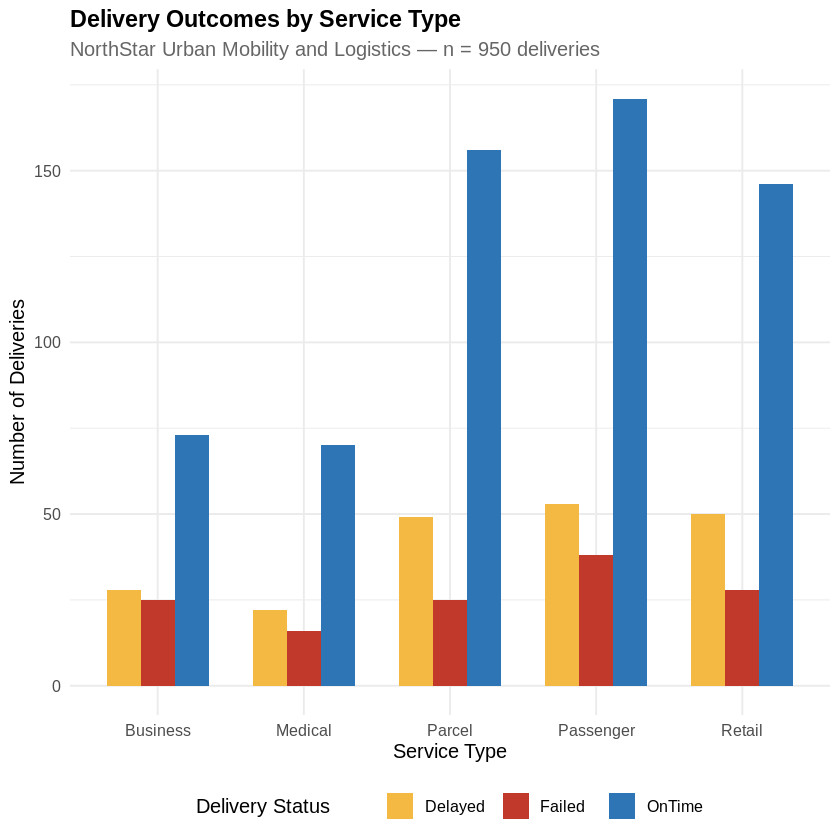

In [ ]:
# Summarise delivery status counts by service type
service_summary <- od %>%
  group_by(service_type, delivery_status) %>%
  summarise(count = n(), .groups = 'drop')
# Define colour palette for delivery status
status_colours <- c('OnTime' = '#2E75B6', 'Delayed' = '#F4B942', 'Failed' = '#C0392B')
# Plot
ggplot(service_summary, aes(x = service_type, y = count, fill = delivery_status)) +
  geom_bar(stat = 'identity', position = 'dodge', width = 0.7) +
  scale_fill_manual(values = status_colours) +
  labs(
    title    = 'Delivery Outcomes by Service Type',
    subtitle = 'NorthStar Urban Mobility and Logistics — n = 950 deliveries',
    x        = 'Service Type',
    y        = 'Number of Deliveries',
    fill     = 'Delivery Status'
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title    = element_text(face = 'bold', size = 14),
    plot.subtitle = element_text(colour = 'grey40'),
    legend.position = 'bottom' )

Chart 2 — Boxplot: Customer Ratings by Delivery Status

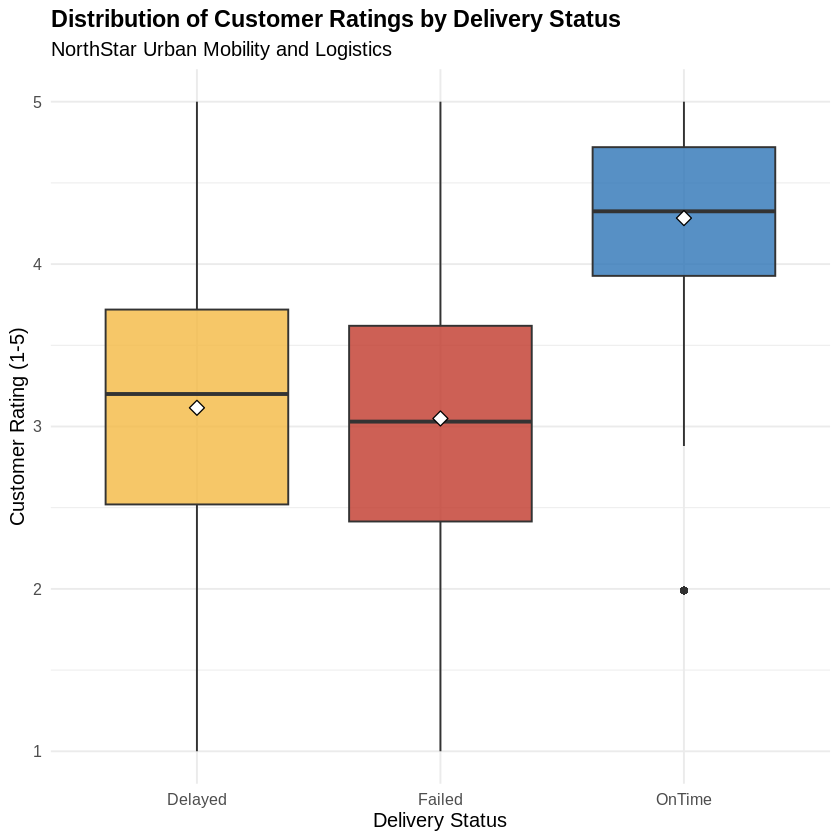

In [ ]:
od_rated <- od[!is.na(od$customer_rating_post_delivery), ]
status_colours <- c('OnTime' = '#2E75B6', 'Delayed' = '#F4B942', 'Failed' = '#C0392B')
ggplot(od_rated, aes(x = delivery_status,
                     y = customer_rating_post_delivery,
                     fill = delivery_status)) +
  geom_boxplot(outlier.colour = 'black', outlier.shape = 16,
               outlier.size = 2, alpha = 0.8) +
  scale_fill_manual(values = status_colours) +
  labs(
    title    = 'Distribution of Customer Ratings by Delivery Status',
    subtitle = 'NorthStar Urban Mobility and Logistics',
    x        = 'Delivery Status',
    y        = 'Customer Rating (1-5)',
    fill     = 'Status') +
  theme_minimal(base_size = 12) +
  theme(plot.title = element_text(face = 'bold', size = 14),
        legend.position = 'none') +
  # Add mean points
  stat_summary(fun = mean, geom = 'point', shape = 23,
               size = 3, fill = 'white', colour = 'black')

 Chart 3 — Scatter Plot: Route Distance vs Fuel Cost by Delivery Status

`geom_smooth()` using formula = 'y ~ x'


Correlation (distance vs fuel cost): 0.524 


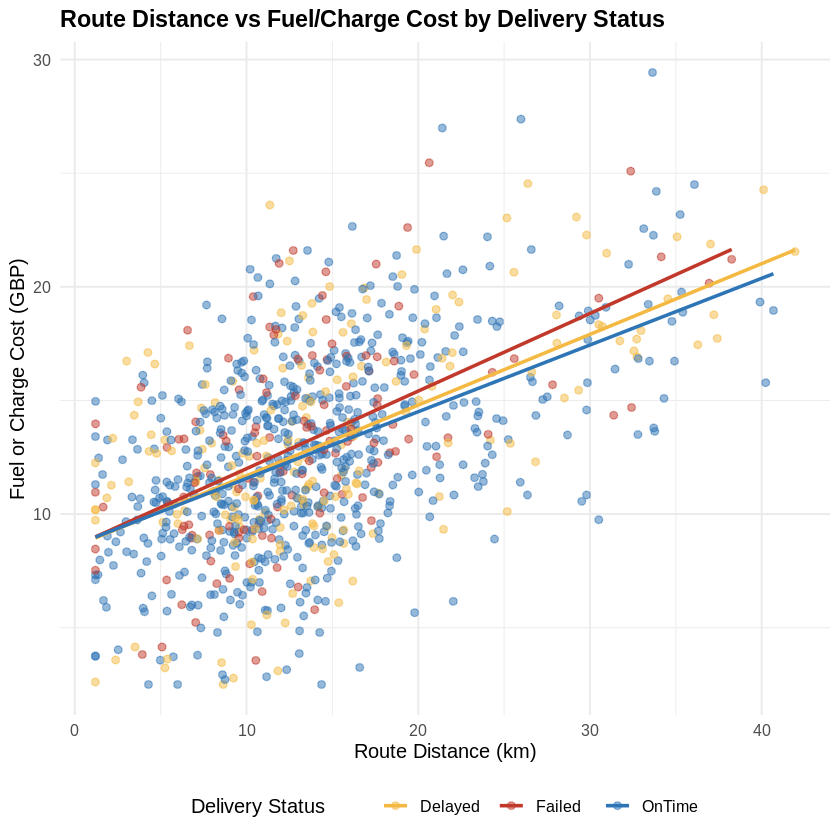

In [ ]:
status_colours <- c('OnTime' = '#2E75B6', 'Delayed' = '#F4B942', 'Failed' = '#C0392B')
ggplot(od, aes(x = route_distance_km,
               y = fuel_or_charge_cost,
               colour = delivery_status)) +
  geom_point(alpha = 0.5, size = 1.8) +
  geom_smooth(method = 'lm', se = FALSE, linewidth = 1) +
  scale_colour_manual(values = status_colours) +
  labs(
    title    = 'Route Distance vs Fuel/Charge Cost by Delivery Status',
    x        = 'Route Distance (km)',
    y        = 'Fuel or Charge Cost (GBP)',
    colour   = 'Delivery Status'
  ) +
  theme_minimal(base_size = 12) +
  theme(plot.title = element_text(face = 'bold', size = 14),
        legend.position = 'bottom')
# Print Pearson correlation
cat('Correlation (distance vs fuel cost):',
    round(cor(od$route_distance_km, od$fuel_or_charge_cost, use='complete.obs'), 3), '\n')

Chart 4 — Heatmap: Failure Rate by Service Type and Zone

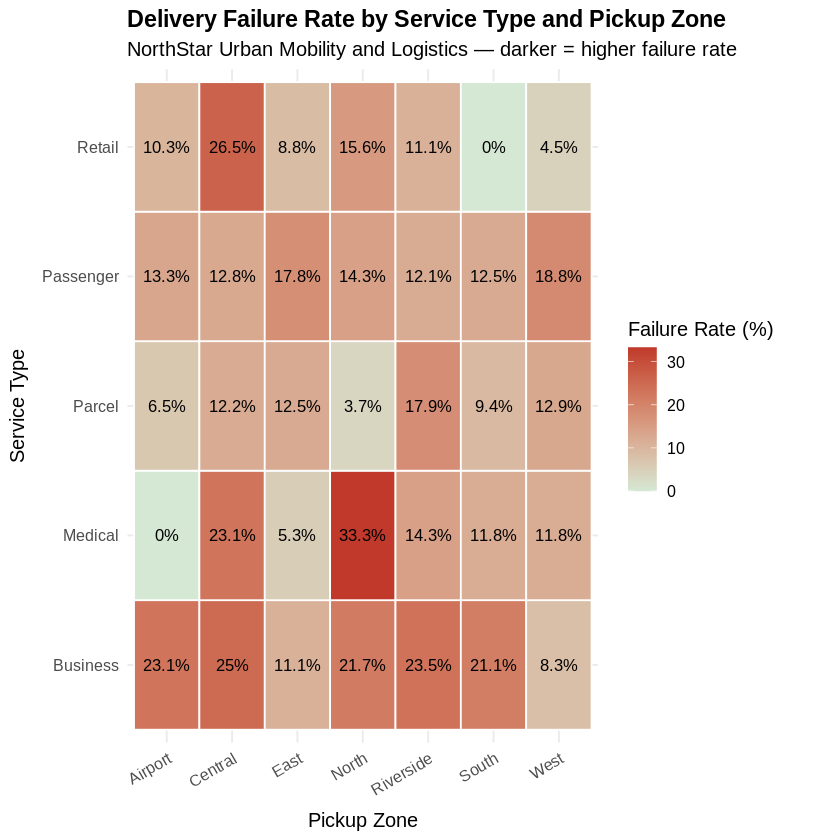

In [ ]:
# Build failure rate summary
heatmap_data <- od %>%
  filter(!is.na(zone_clean)) %>%
  group_by(service_type, zone_clean) %>%
  summarise(
    total        = n(),
    failed       = sum(delivery_status == 'Failed'),
    failure_rate = round(failed / total * 100, 1),
    .groups = 'drop' ) %>%
  filter(total >= 5)   # exclude cells with very low counts
ggplot(heatmap_data, aes(x = zone_clean,
                          y = service_type,
                          fill = failure_rate)) +
  geom_tile(colour = 'white', linewidth = 0.5) +
  geom_text(aes(label = paste0(failure_rate, '%')),
            size = 3.5, colour = 'black') +
  scale_fill_gradient(low = '#D5E8D4', high = '#C0392B',
                      name = 'Failure Rate (%)') +
  labs(
    title    = 'Delivery Failure Rate by Service Type and Pickup Zone',
    x        = 'Pickup Zone',
    y        = 'Service Type') +
  theme_minimal(base_size = 12) +
  theme(
    plot.title   = element_text(face = 'bold', size = 14),
    axis.text.x  = element_text(angle = 30, hjust = 1),
    legend.position = 'right')


Chart 5 — Correlation Analysis: Override Count vs Customer Rating

`geom_smooth()` using formula = 'y ~ x'


Pearson r: -0.0599 
p-value:   0.067 


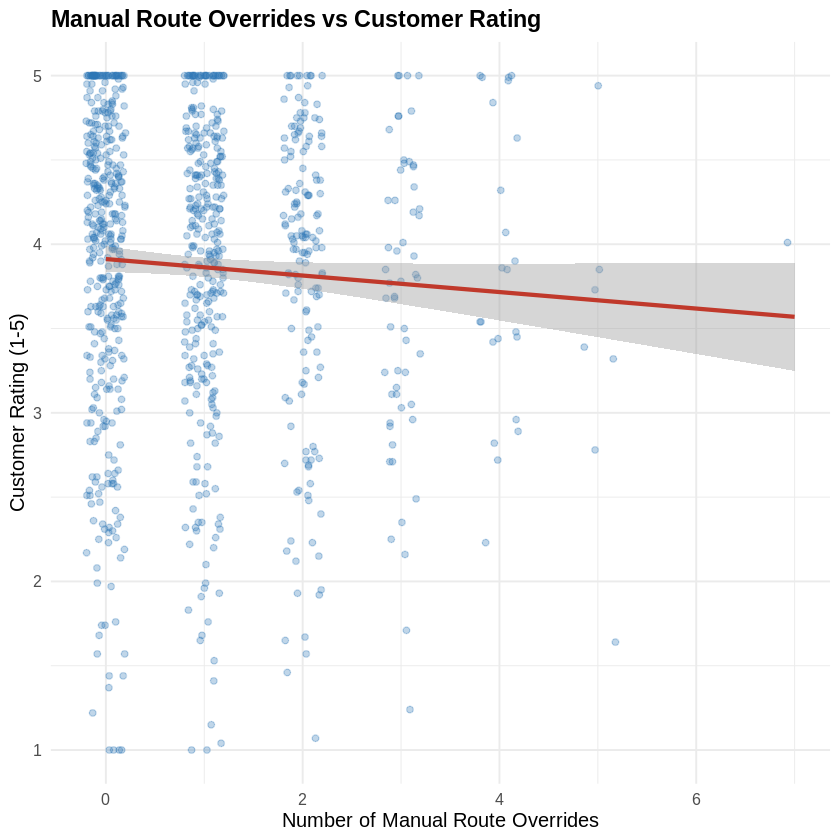

In [ ]:
od_rated <- od[!is.na(od$customer_rating_post_delivery), ]
ggplot(od_rated, aes(x = manual_route_override_count,
                     y = customer_rating_post_delivery)) +
  geom_jitter(alpha = 0.3, colour = '#2E75B6',
              width = 0.2, height = 0, size = 1.5) +
  geom_smooth(method = 'lm', colour = '#C0392B',
              se = TRUE, linewidth = 1.2) +
  labs(
    title    = 'Manual Route Overrides vs Customer Rating',
    x        = 'Number of Manual Route Overrides',
    y        = 'Customer Rating (1-5)'
  ) +
  theme_minimal(base_size = 12) +
  theme(plot.title = element_text(face = 'bold', size = 14))
# Pearson correlation test
cor_test <- cor.test(od_rated$manual_route_override_count,
                     od_rated$customer_rating_post_delivery)
cat('Pearson r:', round(cor_test$estimate, 4), '\n')
cat('p-value:  ', round(cor_test$p.value, 4), '\n')